# Chapter 4 — Framework 1: Cluster-ending taxa poles and site-level taxa matrices



This notebook follows the same chapter-style narrative structure used in Chapter 3 Framework 3 so the analytical workflow can be read from top to bottom while reusable implementation details stay isolated in a Definition Corner.



The execution structure is:



```text

Inputs → Analysis parameters → Definition Corner → Process → Outputs → Visualization

```



The workflow loads the A1 contamination-score artifact together with the A5 and A6 cluster-projection artifacts, constructs cluster-specific ending subsets, summarizes their pole descriptors, materializes the corresponding cluster taxa matrices, and then visualizes the ending-pole taxa composition.


# Inputs

In [31]:
from pathlib import Path
import pandas as pd

STUDY_CASE = "DR"
SITE_ID_COLUMN = "Integrated Code"

if STUDY_CASE == "DR":
    STUDY_CASE_LABEL = "Detroit River case study"
    CASE_ROOT_DIR = Path("../DetroitRiverCase")
else:
    STUDY_CASE_LABEL = "Corridor case study"
    CASE_ROOT_DIR = Path("..")

METADATA_DIR = CASE_ROOT_DIR / "data"
ARTIFACT_DIR = CASE_ROOT_DIR / "artifacts"
RESULTS_DIR = CASE_ROOT_DIR / "results"
FIGURE_DIR = CASE_ROOT_DIR / "figures"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Load site sample information
site_info = pd.read_excel(METADATA_DIR / "Info.xlsx")
site_ids = site_info[SITE_ID_COLUMN].reset_index(drop=True).rename(SITE_ID_COLUMN)

# Load the taxa matrix T and merge with site IDs
T = pd.read_excel(METADATA_DIR / "T.xlsx").reset_index(drop=True)
T_with_site_id = pd.concat([site_ids, T], axis=1)

# Load the A1 stressor-score matrix S_c
A1 = pd.read_excel(ARTIFACT_DIR / "A1_stressors_and_scores.xlsx").reset_index(drop=True)

# Load the artifact A5 - all sites cluster C1 projections
A5 = pd.read_excel(ARTIFACT_DIR / "A5_all_sites_cluster_C1.xlsx").reset_index(drop=True)
# Load the artifact A6 - all sites cluster C2 projections
A6 = pd.read_excel(ARTIFACT_DIR / "A6_all_sites_cluster_C2.xlsx").reset_index(drop=True)
# Load cluster C3 projections if it's DR case
if STUDY_CASE == "DR":
    A7 = pd.read_excel(ARTIFACT_DIR / "A7_all_sites_cluster_C3.xlsx").reset_index(drop=True)

print(f"Study case: {STUDY_CASE_LABEL}")
print(f"Loaded taxa matrix T: {T_with_site_id.shape[0]} sites x {T_with_site_id.shape[1] - 1} taxa variables")
display(T_with_site_id.head())
print(f"Loaded A1 stressor-score matrix: {A1.shape[0]} sites x {A1.shape[1] - 1} variables")
display(A1.head())
print(f"Loaded A5 all sites cluster C1 projections: {A5.shape[0]} sites x {A5.shape[1] - 1} variables")
display(A5.head())
print(f"Loaded A6 all sites cluster C2 projections: {A6.shape[0]} sites x {A6.shape[1] - 1} variables")
display(A6.head())
if STUDY_CASE == "DR":
    print(f"Loaded A7 all sites cluster C3 projections: {A7.shape[0]} sites x {A7.shape[1] - 1} variables")
    display(A7.head())

Study case: Detroit River case study
Loaded taxa matrix T: 213 sites x 16 taxa variables


,Integrated Code,Oligochaeta,Nematoda,Chironomidae,Ceratopogonidae,Hexagenia,Caenis,Hydropsychidae,Other Trichoptera,Amphipoda,Dreissena,Acari,Hydrozoa,Hirudinea,Turbellaria,Gastropoda,Sphaeriidae
0,DR-02,2.269984,0.563546,1.655598,0.0,0.309116,0.000000,2.438439,0.0,4.529993,6.082918,0.000000,0.00000,0.00000,0.0,0.000000,0.0
1,DR-03,3.808504,3.512091,6.242625,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.801982,0.801982,0.00000,0.00000,0.0,0.456015,0.0
2,DR-04,4.820163,5.519382,4.733464,0.0,0.815949,0.000000,0.000000,0.0,0.000000,0.172158,1.010022,0.00000,0.00000,0.0,0.464907,0.0
3,DR-06,1.449187,0.181596,2.271083,0.0,0.999573,0.033941,0.000000,0.0,1.840242,6.475708,0.000000,1.82093,0.23027,0.0,0.000000,0.0
4,DR-07,1.082238,0.246371,2.499653,0.0,0.128438,0.000000,0.128438,0.0,4.224262,6.266368,0.000000,0.00000,0.00000,0.0,0.246371,0.0


Loaded A1 stressor-score matrix: 213 sites x 7 variables


,Integrated Code,PC1,PC2,PC3,PC4,PC5,SumRel,MaxRel
0,DR-02,-5.854877,-1.668737,-0.437252,1.856033,-1.841483,-7.946317,1.856033
1,DR-03,-9.404089,-4.176299,0.800538,-4.173260,-2.464766,-19.417876,0.800538
2,DR-04,-9.421100,-3.999490,-0.395843,0.081539,-2.306848,-16.041743,0.081539
3,DR-06,3.126672,4.326703,1.497875,4.047046,0.436441,13.434738,4.326703
4,DR-07,-7.820020,-2.895044,0.124020,1.153918,-2.253923,-11.691050,1.153918


Loaded A5 all sites cluster C1 projections: 60 sites x 2 variables


,Integrated Code,cluster membership,posterior probability
0,DR-09,C1,0.835334
1,DR-10,C1,0.934377
2,DR-21,C1,0.629373
3,DR-32,C1,0.580940
4,DR-43,C1,0.862858


Loaded A6 all sites cluster C2 projections: 112 sites x 2 variables


,Integrated Code,cluster membership,posterior probability
0,DR-04,C2,0.988314
1,DR-07,C2,0.901587
2,DR-08,C2,0.474130
3,DR-32,C2,0.419011
4,DR-65,C2,0.902228


Loaded A7 all sites cluster C3 projections: 57 sites x 2 variables


,Integrated Code,cluster membership,posterior probability
0,DR-02,C3,0.999815
1,DR-03,C3,0.996759
2,DR-06,C3,0.992654
3,DR-08,C3,0.514080
4,DR-87,C3,0.999984


## Analysis parameters



These parameters control the site-identifier field, the contamination-score field imported from A1, and the size of the low-score and high-score ending subsets extracted from each cluster projection artifact.


In [32]:
SITE_ID_COLUMN = "Integrated Code"
CONTAMINATION_SCORE_COLUMN = "SumRel"
EXTREME_SITE_COUNT = 10



print("Framework 1 parameter setting")
print(f"Site identifier column: {SITE_ID_COLUMN}")
print(f"Contamination score column: {CONTAMINATION_SCORE_COLUMN}")
print(f"Ending subset size m: {EXTREME_SITE_COUNT}")


Framework 1 parameter setting
Site identifier column: Integrated Code
Contamination score column: SumRel
Ending subset size m: 10


# Definition Corner



The following cells define the reusable tools used by the visible workflow below. They can be collapsed during reading so the notebook narrative stays focused on the contamination-score ranking, ending-pole construction, and cluster-specific taxa summaries.


In [33]:
def subset_descriptor_averager(

    descriptor_table: pd.DataFrame,

    interested_site_ids,

    id_col: str = SITE_ID_COLUMN,

    ) -> pd.Series:

    """Average descriptor columns across the rows identified by the supplied site IDs."""

    if id_col not in descriptor_table.columns:

        raise KeyError(f"The descriptor table must contain the identifier column {id_col!r}.")



    target_site_ids = pd.Index(interested_site_ids).astype(str).unique()

    if target_site_ids.empty:

        raise ValueError("At least one target site ID must be supplied.")



    working_table = descriptor_table.copy()

    working_table[id_col] = working_table[id_col].astype(str)

    if working_table[id_col].duplicated().any():

        duplicated_ids = working_table.loc[working_table[id_col].duplicated(), id_col].unique().tolist()[:5]

        raise ValueError(f"Duplicate site IDs found in the descriptor table: {duplicated_ids}")



    matched_rows = working_table.loc[working_table[id_col].isin(target_site_ids)].copy()

    missing_site_ids = [site_id for site_id in target_site_ids if site_id not in set(matched_rows[id_col])]

    if missing_site_ids:

        raise ValueError(f"Requested site IDs were not found in the descriptor table: {missing_site_ids[:10]}")



    descriptor_columns = [column for column in matched_rows.columns if column != id_col]

    if not descriptor_columns:

        raise ValueError("The descriptor table must contain at least one descriptor column.")



    descriptor_values = matched_rows[descriptor_columns].apply(pd.to_numeric, errors="coerce")

    if descriptor_values.isna().any().any():

        incomplete_columns = descriptor_values.columns[descriptor_values.isna().any()].tolist()

        raise ValueError(f"Descriptor columns contain missing or non-numeric values in: {incomplete_columns}")



    average_representer = descriptor_values.mean(axis=0)

    average_representer.name = "average representative"

    return average_representer





def c_score_augmentor(

    cluster_projection_table: pd.DataFrame,

    contamination_score_table: pd.DataFrame,

    score_col: str = CONTAMINATION_SCORE_COLUMN,

    id_col: str = SITE_ID_COLUMN,

    ) -> pd.DataFrame:

    """Append one contamination-score column to a cluster projection table by site ID."""

    required_projection_columns = {id_col}

    required_score_columns = {id_col, score_col}

    if not required_projection_columns.issubset(cluster_projection_table.columns):

        raise KeyError(f"The cluster projection table must contain {sorted(required_projection_columns)}")

    if not required_score_columns.issubset(contamination_score_table.columns):

        raise KeyError(f"The contamination score table must contain {sorted(required_score_columns)}")



    projection_table = cluster_projection_table.copy()

    projection_table[id_col] = projection_table[id_col].astype(str)

    if projection_table[id_col].duplicated().any():

        duplicated_ids = projection_table.loc[projection_table[id_col].duplicated(), id_col].unique().tolist()[:5]

        raise ValueError(f"Duplicate site IDs found in the cluster projection table: {duplicated_ids}")



    score_lookup = contamination_score_table[[id_col, score_col]].copy()

    score_lookup[id_col] = score_lookup[id_col].astype(str)

    if score_lookup[id_col].duplicated().any():

        duplicated_ids = score_lookup.loc[score_lookup[id_col].duplicated(), id_col].unique().tolist()[:5]

        raise ValueError(f"Duplicate site IDs found in the contamination score table: {duplicated_ids}")



    score_lookup[score_col] = pd.to_numeric(score_lookup[score_col], errors="coerce")

    if score_lookup[score_col].isna().any():

        incomplete_ids = score_lookup.loc[score_lookup[score_col].isna(), id_col].tolist()[:10]

        raise ValueError(f"The contamination score column contains missing or non-numeric values for: {incomplete_ids}")



    augmented_table = projection_table.merge(

        score_lookup,

        on=id_col,

        how="left",

        validate="one_to_one",

    )

    missing_ids = augmented_table.loc[augmented_table[score_col].isna(), id_col].tolist()

    if missing_ids:

        raise ValueError(f"Contamination scores were not found for: {missing_ids[:10]}")



    return augmented_table





def symmetric_ending_subset_selector(

    augmented_cluster_table: pd.DataFrame,

    cluster_label: str,

    score_col: str = CONTAMINATION_SCORE_COLUMN,

    extreme_count: int = EXTREME_SITE_COUNT,

    id_col: str = SITE_ID_COLUMN,

    ) -> dict[str, pd.DataFrame]:

    """Return the lowest-score reference set and highest-score degraded set for one cluster."""

    required_columns = {id_col, score_col}

    if not required_columns.issubset(augmented_cluster_table.columns):

        raise KeyError(f"The augmented cluster table must contain {sorted(required_columns)}")

    if extreme_count <= 0:

        raise ValueError("extreme_count must be a positive integer.")



    working_table = augmented_cluster_table.copy()

    working_table[id_col] = working_table[id_col].astype(str)

    working_table[score_col] = pd.to_numeric(working_table[score_col], errors="coerce")

    if working_table[score_col].isna().any():

        incomplete_ids = working_table.loc[working_table[score_col].isna(), id_col].tolist()[:10]

        raise ValueError(f"The contamination score column contains missing or non-numeric values for: {incomplete_ids}")

    if 2 * extreme_count > working_table.shape[0]:

        raise ValueError("extreme_count is too large to select non-overlapping ending subsets.")



    ranked_table = working_table.sort_values([score_col, id_col], ascending=[True, True]).reset_index(drop=True)

    return {

        f"{cluster_label} ref set": ranked_table.head(extreme_count).reset_index(drop=True),

        f"{cluster_label} deg set": ranked_table.tail(extreme_count).reset_index(drop=True),

    }





def cluster_taxa_matrix_slicer(

    descriptor_table: pd.DataFrame,

    cluster_projection_table: pd.DataFrame,

    id_col: str = SITE_ID_COLUMN,

    ) -> pd.DataFrame:

    """Slice the taxa descriptor matrix to the unique site IDs represented in one cluster artifact."""

    if id_col not in descriptor_table.columns:

        raise KeyError(f"The descriptor table must contain the identifier column {id_col!r}.")

    if id_col not in cluster_projection_table.columns:

        raise KeyError(f"The cluster projection table must contain the identifier column {id_col!r}.")



    target_site_ids = pd.Index(cluster_projection_table[id_col]).astype(str).unique()

    if target_site_ids.empty:

        raise ValueError("At least one cluster site ID must be supplied.")



    working_table = descriptor_table.copy()

    working_table[id_col] = working_table[id_col].astype(str)

    if working_table[id_col].duplicated().any():

        duplicated_ids = working_table.loc[working_table[id_col].duplicated(), id_col].unique().tolist()[:5]

        raise ValueError(f"Duplicate site IDs found in the descriptor table: {duplicated_ids}")



    matched_rows = working_table.loc[working_table[id_col].isin(target_site_ids)].copy()

    missing_site_ids = [site_id for site_id in target_site_ids if site_id not in set(matched_rows[id_col])]

    if missing_site_ids:

        raise ValueError(f"Requested site IDs were not found in the descriptor table: {missing_site_ids[:10]}")



    descriptor_columns = [column for column in matched_rows.columns if column != id_col]

    if not descriptor_columns:

        raise ValueError("The descriptor table must contain at least one descriptor column.")



    descriptor_values = matched_rows[descriptor_columns].apply(pd.to_numeric, errors="coerce")

    if descriptor_values.isna().any().any():

        incomplete_columns = descriptor_values.columns[descriptor_values.isna().any()].tolist()

        raise ValueError(f"Descriptor columns contain missing or non-numeric values in: {incomplete_columns}")



    descriptor_values.index = matched_rows[id_col].astype(str)

    descriptor_values = descriptor_values.loc[target_site_ids]

    descriptor_values.index.name = id_col

    return descriptor_values





def pole_appender(

    cluster_poles_table: pd.DataFrame,

    cluster_taxa_descriptors: pd.DataFrame,

    ) -> pd.DataFrame:

    """Append the pole rows to a cluster taxa descriptor matrix."""

    if cluster_taxa_descriptors.empty:

        raise ValueError("cluster_taxa_descriptors must contain at least one row.")

    if cluster_taxa_descriptors.index.has_duplicates:

        duplicated_ids = cluster_taxa_descriptors.index[cluster_taxa_descriptors.index.duplicated()].unique().tolist()[:5]

        raise ValueError(f"Duplicate site IDs found in cluster_taxa_descriptors: {duplicated_ids}")

    if cluster_poles_table.empty:

        raise ValueError("cluster_poles_table must contain at least one row.")



    working_taxa_descriptors = cluster_taxa_descriptors.copy()

    working_taxa_descriptors.index = working_taxa_descriptors.index.astype(str)



    working_poles_table = cluster_poles_table.copy()

    working_poles_table.index = working_poles_table.index.astype(str)



    missing_in_poles = [column for column in working_taxa_descriptors.columns if column not in working_poles_table.columns]

    extra_in_poles = [column for column in working_poles_table.columns if column not in working_taxa_descriptors.columns]

    if missing_in_poles or extra_in_poles:

        raise ValueError(

            "cluster_poles_table columns must match cluster_taxa_descriptors columns. "

            f"Missing in poles: {missing_in_poles[:10]}; extra in poles: {extra_in_poles[:10]}"

        )



    working_poles_table = working_poles_table.loc[:, working_taxa_descriptors.columns]

    working_poles_table = working_poles_table.apply(pd.to_numeric, errors="coerce")

    if working_poles_table.isna().any().any():

        incomplete_columns = working_poles_table.columns[working_poles_table.isna().any()].tolist()

        raise ValueError(f"Pole rows contain missing or non-numeric values in: {incomplete_columns}")



    overlapping_ids = sorted(set(working_taxa_descriptors.index).intersection(working_poles_table.index))

    if overlapping_ids:

        raise ValueError(f"Pole labels overlap with existing site IDs: {overlapping_ids[:10]}")



    taxa_descriptor_matrix_with_poles = pd.concat([

        working_taxa_descriptors,

        working_poles_table,

    ])

    taxa_descriptor_matrix_with_poles.index.name = working_taxa_descriptors.index.name or SITE_ID_COLUMN

    return taxa_descriptor_matrix_with_poles


In [34]:
def build_bray_curtis_dissimilarity_matrix(

    taxa_descriptor_matrix: pd.DataFrame,

    octave_scale: float = 100.0,

    octave_offset: float = 0.01,

) -> pd.DataFrame:

    """Recover proportional taxa values and return the pairwise Bray-Curtis dissimilarity matrix."""

    if taxa_descriptor_matrix.empty:

        raise ValueError("taxa_descriptor_matrix must contain at least one row.")

    if taxa_descriptor_matrix.index.has_duplicates:

        duplicated_ids = taxa_descriptor_matrix.index[taxa_descriptor_matrix.index.duplicated()].unique().tolist()[:5]

        raise ValueError(f"Duplicate row labels found in taxa_descriptor_matrix: {duplicated_ids}")



    descriptor_values = taxa_descriptor_matrix.copy().apply(pd.to_numeric, errors="coerce")

    if descriptor_values.isna().any().any():

        incomplete_columns = descriptor_values.columns[descriptor_values.isna().any()].tolist()

        raise ValueError(f"taxa_descriptor_matrix contains missing or non-numeric values in: {incomplete_columns}")



    proportional_values = ((2.0 ** descriptor_values) / octave_scale - octave_offset).clip(lower=0.0)

    labels = pd.Index(taxa_descriptor_matrix.index).astype(str)



    if proportional_values.shape[0] == 1:

        dissimilarity_matrix = pd.DataFrame([[0.0]], index=labels, columns=labels)

    else:

        from scipy.spatial.distance import pdist, squareform



        dissimilarity_values = squareform(

            pdist(proportional_values.to_numpy(dtype=float), metric="braycurtis")

        )

        dissimilarity_matrix = pd.DataFrame(dissimilarity_values, index=labels, columns=labels)



    dissimilarity_matrix.index.name = taxa_descriptor_matrix.index.name or SITE_ID_COLUMN

    dissimilarity_matrix.columns.name = taxa_descriptor_matrix.index.name or SITE_ID_COLUMN

    return dissimilarity_matrix


In [35]:
import matplotlib.pyplot as plt
import numpy as np

DEFAULT_CLUSTER_PALETTE = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
DEFAULT_TAXON_ORDER = [
    "Oligochaeta",
    "Chironomidae",
    "Nematoda",
    "Sphaeriidae",
    "Acari",
    "Hexagenia",
    "Caenis",
    "Hirudinea",
    "Turbellaria",
    "Gastropoda",
    "Hydrozoa",
    "Other Trichoptera",
    "Amphipoda",
    "Hydropsychidae",
    "Dreissena",
    "Ceratopogonidae",
]


def _select_numeric_descriptor_rows(
    descriptor_table: pd.DataFrame,
    interested_site_ids,
    id_col: str = SITE_ID_COLUMN,
    ) -> pd.DataFrame:
    if id_col not in descriptor_table.columns:
        raise KeyError(f"The descriptor table must contain the identifier column {id_col!r}.")

    target_site_ids = pd.Index(interested_site_ids).astype(str).unique()
    if target_site_ids.empty:
        raise ValueError("At least one target site ID must be supplied.")

    working_table = descriptor_table.copy()
    working_table[id_col] = working_table[id_col].astype(str)
    if working_table[id_col].duplicated().any():
        duplicated_ids = working_table.loc[working_table[id_col].duplicated(), id_col].unique().tolist()[:5]
        raise ValueError(f"Duplicate site IDs found in the descriptor table: {duplicated_ids}")

    matched_rows = working_table.loc[working_table[id_col].isin(target_site_ids)].copy()
    missing_site_ids = [site_id for site_id in target_site_ids if site_id not in set(matched_rows[id_col])]
    if missing_site_ids:
        raise ValueError(f"Requested site IDs were not found in the descriptor table: {missing_site_ids[:10]}")

    descriptor_columns = [column for column in matched_rows.columns if column != id_col]
    if not descriptor_columns:
        raise ValueError("The descriptor table must contain at least one descriptor column.")

    descriptor_values = matched_rows[descriptor_columns].apply(pd.to_numeric, errors="coerce")
    if descriptor_values.isna().any().any():
        incomplete_columns = descriptor_values.columns[descriptor_values.isna().any()].tolist()
        raise ValueError(f"Descriptor columns contain missing or non-numeric values in: {incomplete_columns}")

    descriptor_values.index = matched_rows[id_col].astype(str).tolist()
    descriptor_values.index.name = id_col
    return descriptor_values


def subset_descriptor_averager(
    descriptor_table: pd.DataFrame,
    interested_site_ids,
    id_col: str = SITE_ID_COLUMN,
    ) -> pd.Series:
    """Average descriptor columns across the rows identified by the supplied site IDs."""
    descriptor_values = _select_numeric_descriptor_rows(
        descriptor_table,
        interested_site_ids,
        id_col=id_col,
    )
    average_representer = descriptor_values.mean(axis=0)
    average_representer.name = "average representative"
    return average_representer


def subset_descriptor_standard_error(
    descriptor_table: pd.DataFrame,
    interested_site_ids,
    id_col: str = SITE_ID_COLUMN,
    ) -> pd.Series:
    """Return the column-wise standard error for the rows identified by the supplied site IDs."""
    descriptor_values = _select_numeric_descriptor_rows(
        descriptor_table,
        interested_site_ids,
        id_col=id_col,
    )
    if descriptor_values.shape[0] == 1:
        standard_error = pd.Series(0.0, index=descriptor_values.columns)
    else:
        standard_error = descriptor_values.std(axis=0, ddof=1) / np.sqrt(descriptor_values.shape[0])
    standard_error.name = "standard error"
    return standard_error


def _invert_octave_to_proportion(
    value: float,
    octave_scale: float = 100.0,
    octave_offset: float = 0.01,
    ) -> float:
    if pd.isna(value):
        return np.nan
    return max((2.0 ** float(value)) / octave_scale - octave_offset, 0.0)


def _equal_gap_relative_scale(
    value: float,
    first_gap: float = 0.02,
    ) -> float:
    if pd.isna(value) or value <= 0.0:
        return 0.0
    if value <= first_gap:
        return float(value / first_gap)
    return float(1.0 + np.log2(value / first_gap))


def _build_equal_gap_ticks(
    max_value: float,
    first_gap: float = 0.02,
    ) -> tuple[np.ndarray, list[str]]:
    tick_values = [0.0]
    tick_value = first_gap
    target_max = max(float(max_value), first_gap)
    while tick_value < target_max:
        tick_values.append(tick_value)
        tick_value *= 2.0
    tick_values.append(tick_value)

    tick_positions = np.array([
        _equal_gap_relative_scale(tick, first_gap=first_gap)
        for tick in tick_values
    ], dtype=float)
    tick_labels = [
        "0%" if np.isclose(tick, 0.0) else f"{int(round(tick * 100))}%"
        for tick in tick_values
    ]
    return tick_positions, tick_labels


def render_cluster_ending_barplot(
    ending_subsets: dict[str, pd.DataFrame],
    descriptor_table: pd.DataFrame,
    cluster_label: str,
    taxon_order: list[str] | None = None,
    palette: list[str] | None = None,
    id_col: str = SITE_ID_COLUMN,
    figsize: tuple[float, float] = (16, 7),
    dpi: int = 300,
    ) -> tuple[plt.Figure, plt.Axes]:
    """Render one cluster's reference and degraded ending poles with upper-only SE bars."""
    taxon_order = taxon_order or DEFAULT_TAXON_ORDER
    palette = palette or DEFAULT_CLUSTER_PALETTE

    subset_order = [f"{cluster_label} ref set", f"{cluster_label} deg set"]
    available_subset_order = [subset_name for subset_name in subset_order if subset_name in ending_subsets]
    if len(available_subset_order) != 2:
        raise ValueError(f"Expected exactly two ending subsets for {cluster_label}.")

    ordered_taxa = [taxon for taxon in taxon_order if taxon in descriptor_table.columns]
    remaining_taxa = [column for column in descriptor_table.columns if column not in set(ordered_taxa) | {id_col}]
    ordered_taxa.extend(remaining_taxa)

    summary_by_subset: dict[str, dict[str, pd.Series]] = {}
    for subset_name in available_subset_order:
        interested_site_ids = ending_subsets[subset_name][id_col]
        mean_series = subset_descriptor_averager(
            descriptor_table,
            interested_site_ids,
            id_col=id_col,
        ).loc[ordered_taxa]
        se_series = subset_descriptor_standard_error(
            descriptor_table,
            interested_site_ids,
            id_col=id_col,
        ).loc[ordered_taxa]
        summary_by_subset[subset_name] = {
            "mean": mean_series,
            "se": se_series,
        }

    x_positions = np.arange(len(ordered_taxa))
    bar_width = 0.8 / len(available_subset_order)
    offsets = np.linspace(-0.4 + bar_width / 2.0, 0.4 - bar_width / 2.0, len(available_subset_order))

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    overall_max = 0.0
    for offset, subset_name, color in zip(offsets, available_subset_order, palette):
        mean_series = summary_by_subset[subset_name]["mean"]
        se_series = summary_by_subset[subset_name]["se"]

        mean_display = mean_series.map(_invert_octave_to_proportion)
        upper_display = (mean_series + se_series).map(_invert_octave_to_proportion)

        mean_positions = np.array([
            _equal_gap_relative_scale(value)
            for value in mean_display
        ], dtype=float)
        upper_positions = np.array([
            _equal_gap_relative_scale(value)
            for value in upper_display
        ], dtype=float)
        upper_error_values = np.clip(upper_positions - mean_positions, a_min=0.0, a_max=None)

        overall_max = max(overall_max, float(np.nanmax(upper_display.to_numpy(dtype=float))))

        legend_label = subset_name.replace(f"{cluster_label} ", "").replace(" set", " pole").title()
        ax.bar(
            x_positions + offset,
            mean_positions,
            width=bar_width,
            yerr=np.vstack([np.zeros_like(upper_error_values), upper_error_values]),
            color=color,
            edgecolor="black",
            linewidth=0.3,
            error_kw={"elinewidth": 1.0, "capsize": 2},
            label=legend_label,
        )

    y_tick_positions, y_tick_labels = _build_equal_gap_ticks(overall_max)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(ordered_taxa, rotation=35, ha="right", fontsize=10)
    ax.set_yticks(y_tick_positions)
    ax.set_yticklabels(y_tick_labels)
    ax.set_ylabel("Mean Relative Abundance (+SE)", fontsize=13, fontweight="bold")
    ax.set_title(f"{cluster_label} Ending Poles", fontsize=16, fontweight="bold")
    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
    ax.set_axisbelow(True)
    ax.set_ylim(0, float(y_tick_positions[-1]))
    ax.legend(loc="upper right", frameon=True, fontsize=10)
    fig.tight_layout()
    return fig, ax

# Process



The visible workflow below augments the cluster artifacts with contamination scores, extracts the ending subsets, builds the pole tables and cluster-specific taxa matrices, and prepares the ending-pole figures for later display.


In [36]:
A5_augmented = c_score_augmentor(
    cluster_projection_table=A5,
    contamination_score_table=A1,
    score_col=CONTAMINATION_SCORE_COLUMN,
    id_col=SITE_ID_COLUMN,
)

A6_augmented = c_score_augmentor(
    cluster_projection_table=A6,
    contamination_score_table=A1,
    score_col=CONTAMINATION_SCORE_COLUMN,
    id_col=SITE_ID_COLUMN,
)

# add A7 augmentation if it's DR case
if STUDY_CASE == "DR":
    A7_augmented = c_score_augmentor(
        cluster_projection_table=A7,
        contamination_score_table=A1,
        score_col=CONTAMINATION_SCORE_COLUMN,
        id_col=SITE_ID_COLUMN,
    )

C1_ending_subsets = symmetric_ending_subset_selector(
    augmented_cluster_table=A5_augmented,
    cluster_label="C1",
    score_col=CONTAMINATION_SCORE_COLUMN,
    extreme_count=EXTREME_SITE_COUNT,
    id_col=SITE_ID_COLUMN,
)

C2_ending_subsets = symmetric_ending_subset_selector(
    augmented_cluster_table=A6_augmented,
    cluster_label="C2",
    score_col=CONTAMINATION_SCORE_COLUMN,
    extreme_count=EXTREME_SITE_COUNT,
    id_col=SITE_ID_COLUMN,
)

# add C3 ending subsets if it's DR case
if STUDY_CASE == "DR":
    C3_ending_subsets = symmetric_ending_subset_selector(
        augmented_cluster_table=A7_augmented,
        cluster_label="C3",
        score_col=CONTAMINATION_SCORE_COLUMN,
        extreme_count=EXTREME_SITE_COUNT,
        id_col=SITE_ID_COLUMN,
    )

C1_poles = {
    subset_name.replace(" set", " pole"): subset_descriptor_averager(
        descriptor_table=T_with_site_id,
        interested_site_ids=subset_table[SITE_ID_COLUMN],
        id_col=SITE_ID_COLUMN,
    )
    for subset_name, subset_table in C1_ending_subsets.items()
}

C2_poles = {
    subset_name.replace(" set", " pole"): subset_descriptor_averager(
        descriptor_table=T_with_site_id,
        interested_site_ids=subset_table[SITE_ID_COLUMN],
        id_col=SITE_ID_COLUMN,
    )
    for subset_name, subset_table in C2_ending_subsets.items()
}

# add C3 poles if it's DR case
if STUDY_CASE == "DR":
    C3_poles = {
        subset_name.replace(" set", " pole"): subset_descriptor_averager(
            descriptor_table=T_with_site_id,
            interested_site_ids=subset_table[SITE_ID_COLUMN],
            id_col=SITE_ID_COLUMN,
        )
        for subset_name, subset_table in C3_ending_subsets.items()
    }

C1_poles_table = pd.DataFrame(C1_poles).T
C2_poles_table = pd.DataFrame(C2_poles).T
if STUDY_CASE == "DR":
    C3_poles_table = pd.DataFrame(C3_poles).T

In [37]:
c1_taxa_descriptors = cluster_taxa_matrix_slicer(
    descriptor_table=T_with_site_id,
    cluster_projection_table=A5,
    id_col=SITE_ID_COLUMN,
)

c2_taxa_descriptors = cluster_taxa_matrix_slicer(
    descriptor_table=T_with_site_id,
    cluster_projection_table=A6,
    id_col=SITE_ID_COLUMN,
)

# add C3 taxa descriptors if it's DR case
if STUDY_CASE == "DR":
    c3_taxa_descriptors = cluster_taxa_matrix_slicer(
        descriptor_table=T_with_site_id,
        cluster_projection_table=A7,
        id_col=SITE_ID_COLUMN,
    )

c1_taxa_descriptor_matrix_with_poles = pole_appender(
    cluster_poles_table=C1_poles_table,
    cluster_taxa_descriptors=c1_taxa_descriptors,
)

c2_taxa_descriptor_matrix_with_poles = pole_appender(
    cluster_poles_table=C2_poles_table,
    cluster_taxa_descriptors=c2_taxa_descriptors,
)
# add C3 taxa descriptor matrix with poles if it's DR case
if STUDY_CASE == "DR":
    c3_taxa_descriptor_matrix_with_poles = pole_appender(
        cluster_poles_table=C3_poles_table,
        cluster_taxa_descriptors=c3_taxa_descriptors,
    )

c1_bray_curtis_dissimilarity_matrix = build_bray_curtis_dissimilarity_matrix(
    c1_taxa_descriptor_matrix_with_poles,
)

c2_bray_curtis_dissimilarity_matrix = build_bray_curtis_dissimilarity_matrix(
    c2_taxa_descriptor_matrix_with_poles,
)
# add C3 Bray-Curtis dissimilarity matrix if it's DR case
if STUDY_CASE == "DR":
    c3_bray_curtis_dissimilarity_matrix = build_bray_curtis_dissimilarity_matrix(
        c3_taxa_descriptor_matrix_with_poles,
    )

with plt.ioff():
    C1_barplot_figure, C1_barplot_axis = render_cluster_ending_barplot(
        C1_ending_subsets,
        T_with_site_id,
        cluster_label="C1",
    )
    C1_barplot_axis.set_ylabel("Mean Relative Abundance (+SE)", fontsize=17, fontweight="bold")
    C1_barplot_axis.tick_params(axis="x", labelsize=18)
    C1_barplot_axis.tick_params(axis="y", labelsize=18)
    C1_legend = C1_barplot_axis.get_legend()

    if C1_legend is not None:
        for text in C1_legend.get_texts():
            text.set_fontsize(16)
            
    C2_barplot_figure, C2_barplot_axis = render_cluster_ending_barplot(
        C2_ending_subsets,
        T_with_site_id,
        cluster_label="C2",
    )
    
    C2_barplot_axis.set_ylabel("Mean Relative Abundance (+SE)", fontsize=17, fontweight="bold")
    C2_barplot_axis.tick_params(axis="x", labelsize=18)
    C2_barplot_axis.tick_params(axis="y", labelsize=18)
    C2_legend = C2_barplot_axis.get_legend()
    if C2_legend is not None:
        for text in C2_legend.get_texts():
            text.set_fontsize(16)
    
    # add C3 barplot rendering if it's DR case
    if STUDY_CASE == "DR":
        C3_barplot_figure, C3_barplot_axis = render_cluster_ending_barplot(
            C3_ending_subsets,
            T_with_site_id,
            cluster_label="C3",
        )
        C3_barplot_axis.set_ylabel("Mean Relative Abundance (+SE)", fontsize=17, fontweight="bold")
        C3_barplot_axis.tick_params(axis="x", labelsize=18)
        C3_barplot_axis.tick_params(axis="y", labelsize=18)
        C3_legend = C3_barplot_axis.get_legend()
        if C3_legend is not None:
            for text in C3_legend.get_texts():
                text.set_fontsize(16)

# Outputs



Display the cluster-ending tables and taxa-matrix summaries produced by the process workflow above.


In [39]:
print(f"C1 ending-pole table; Shape: {C1_poles_table.shape[0]} poles × {C1_poles_table.shape[1]} taxa")
display(C1_poles_table)
print(f"C2 ending-pole table; Shape: {C2_poles_table.shape[0]} poles × {C2_poles_table.shape[1]} taxa")
display(C2_poles_table)
if STUDY_CASE == "DR":
    print(f"C3 ending-pole table; Shape: {C3_poles_table.shape[0]} poles × {C3_poles_table.shape[1]} taxa")
    display(C3_poles_table)

print(f"C1 taxa descriptor matrix with poles; Shape: {c1_taxa_descriptor_matrix_with_poles.shape[0]} sites × {c1_taxa_descriptor_matrix_with_poles.shape[1]} taxa")
display(c1_taxa_descriptor_matrix_with_poles.tail())
print(f"C2 taxa descriptor matrix with poles; Shape: {c2_taxa_descriptor_matrix_with_poles.shape[0]} sites × {c2_taxa_descriptor_matrix_with_poles.shape[1]} taxa")
display(c2_taxa_descriptor_matrix_with_poles.tail())
if STUDY_CASE == "DR":
    print(f"C3 taxa descriptor matrix with poles; Shape: {c3_taxa_descriptor_matrix_with_poles.shape[0]} sites × {c3_taxa_descriptor_matrix_with_poles.shape[1]} taxa")
    display(c3_taxa_descriptor_matrix_with_poles.tail())

print(f"C1 Bray-Curtis dissimilarity matrix; Shape: {c1_bray_curtis_dissimilarity_matrix.shape[0]} sites × {c1_bray_curtis_dissimilarity_matrix.shape[1]} sites")
display(c1_bray_curtis_dissimilarity_matrix.head())
# save the c1 bray-curtis dissimilarity matrix to the artifacts directory
if STUDY_CASE == "DR":
    c1_bray_curtis_dissimilarity_matrix.to_excel(ARTIFACT_DIR / "A8_C1_bray_curtis_dissimilarity_matrix.xlsx")
else:
    c1_bray_curtis_dissimilarity_matrix.to_excel(ARTIFACT_DIR / "A7_C1_bray_curtis_dissimilarity_matrix.xlsx")

print(f"C2 Bray-Curtis dissimilarity matrix; Shape: {c2_bray_curtis_dissimilarity_matrix.shape[0]} sites × {c2_bray_curtis_dissimilarity_matrix.shape[1]} sites")
display(c2_bray_curtis_dissimilarity_matrix.head())
# save the c2 bray-curtis dissimilarity matrix to the artifacts directory
if STUDY_CASE == "DR":
    c2_bray_curtis_dissimilarity_matrix.to_excel(ARTIFACT_DIR / "A9_C2_bray_curtis_dissimilarity_matrix.xlsx")
else:
    c2_bray_curtis_dissimilarity_matrix.to_excel(ARTIFACT_DIR / "A8_C2_bray_curtis_dissimilarity_matrix.xlsx")

if STUDY_CASE == "DR":
    print(f"C3 Bray-Curtis dissimilarity matrix; Shape: {c3_bray_curtis_dissimilarity_matrix.shape[0]} sites × {c3_bray_curtis_dissimilarity_matrix.shape[1]} sites")
    display(c3_bray_curtis_dissimilarity_matrix.head())
    # save the c3 bray-curtis dissimilarity matrix to the artifacts directory
    c3_bray_curtis_dissimilarity_matrix.to_excel(ARTIFACT_DIR / "A10_C3_bray_curtis_dissimilarity_matrix.xlsx")

C1 ending-pole table; Shape: 2 poles × 16 taxa


,Oligochaeta,Nematoda,Chironomidae,Ceratopogonidae,Hexagenia,Caenis,Hydropsychidae,Other Trichoptera,Amphipoda,Dreissena,Acari,Hydrozoa,Hirudinea,Turbellaria,Gastropoda,Sphaeriidae
C1 ref pole,4.725777,1.923325,3.047371,0.541224,0.051276,0.305815,0.625331,0.187680,2.071131,1.733786,0.364298,0.422807,0.175584,0.644594,0.775927,0.530387
C1 deg pole,6.467909,0.145816,0.704440,0.000000,0.011339,0.000000,0.140100,0.067697,0.775347,0.475152,0.035529,0.824527,0.071805,0.700512,0.745535,1.958524


C2 ending-pole table; Shape: 2 poles × 16 taxa


,Oligochaeta,Nematoda,Chironomidae,Ceratopogonidae,Hexagenia,Caenis,Hydropsychidae,Other Trichoptera,Amphipoda,Dreissena,Acari,Hydrozoa,Hirudinea,Turbellaria,Gastropoda,Sphaeriidae
C2 ref pole,4.618133,4.199040,4.182377,0.000000,0.262330,0.180735,0.251525,0.000000,0.136888,0.197951,0.46477,0.509503,0.000000,0.310698,0.203830,0.445695
C2 deg pole,5.981311,1.972354,2.858338,0.779024,0.725691,0.072935,0.152774,0.007923,0.784230,0.396404,0.18606,0.311210,0.089583,0.060217,0.902622,0.356096


C3 ending-pole table; Shape: 2 poles × 16 taxa


...

Integrated Code,DR-09,DR-10,DR-21,DR-32,DR-43,DR-54,DR-76,DR-98,DR-142,DR-193,...,DR-113,DR-114,DR-121,DR-128,DR-134,DR-135,DR-138,DR-150,C1 ref pole,C1 deg pole
Integrated Code,,,,,,,,,,,,,,,,,,,,,
DR-09,0.000000,0.927602,0.932127,0.876183,0.451357,0.624030,0.927602,0.904728,0.087736,0.898004,...,0.975765,0.981399,0.493405,0.953893,0.970172,0.922816,0.987707,0.922226,0.813905,0.971595
DR-10,0.927602,0.000000,0.311005,0.279720,0.580711,0.646645,0.186976,0.226022,0.986732,0.430054,...,0.819580,0.866140,0.942376,0.873494,0.841739,0.783211,0.869248,0.710471,0.683669,0.867571
DR-21,0.932127,0.311005,0.000000,0.118758,0.561066,0.576128,0.220231,0.157573,0.986732,0.348474,...,0.731611,0.759463,0.942580,0.766636,0.736778,0.676353,0.763208,0.608129,0.536918,0.757975
DR-32,0.876183,0.279720,0.118758,0.000000,0.467657,0.502123,0.215890,0.102970,0.930788,0.369719,...,0.724533,0.775382,0.886636,0.767335,0.748065,0.687640,0.779716,0.614900,0.528150,0.765044
DR-43,0.451357,0.580711,0.561066,0.467657,0.000000,0.243132,0.638093,0.472565,0.505963,0.762513,...,0.710732,0.764386,0.615862,0.745132,0.728738,0.673144,0.768353,0.600628,0.479718,0.753760


C2 Bray-Curtis dissimilarity matrix; Shape: 114 sites × 114 sites


Integrated Code,DR-04,DR-07,DR-08,DR-32,DR-65,DR-98,DR-131,DR-153,DR-175,DR-177,...,DR-144,DR-145,DR-152,DR-154,DR-156,DR-157,DR-158,DR-159,C2 ref pole,C2 deg pole
Integrated Code,,,,,,,,,,,,,,,,,,,,,
DR-04,0.000000,0.936349,0.530942,0.449006,0.142369,0.395356,0.437611,0.384996,0.549765,0.448227,...,0.339901,0.369013,0.819727,0.298833,0.360372,0.567879,0.525390,0.644170,0.265138,0.570255
DR-07,0.936349,0.000000,0.942272,0.884466,0.940410,0.921130,0.914479,0.940410,0.881586,0.940410,...,0.940410,0.939479,0.879724,0.940410,0.940410,0.935255,0.974415,0.940668,0.918413,0.916043
DR-08,0.530942,0.942272,0.000000,0.146752,0.531279,0.200771,0.307609,0.202507,0.632396,0.425008,...,0.206851,0.598988,0.867860,0.527018,0.408213,0.710444,0.784552,0.750805,0.526716,0.694752
DR-32,0.449006,0.884466,0.146752,0.000000,0.440471,0.102970,0.265210,0.111699,0.571452,0.394861,...,0.130536,0.517614,0.816536,0.450703,0.317405,0.635571,0.693744,0.706876,0.416824,0.644181
DR-65,0.142369,0.940410,0.531279,0.440471,0.000000,0.385553,0.316772,0.328772,0.419360,0.318516,...,0.340238,0.258538,0.823529,0.189065,0.230661,0.458110,0.405481,0.524262,0.270555,0.445704


C3 Bray-Curtis dissimilarity matrix; Shape: 59 sites × 59 sites


Integrated Code,DR-02,DR-03,DR-06,DR-08,DR-87,DR-109,DR-120,DR-142,DR-160,DR-161,...,DR-141,DR-146,DR-147,DR-148,DR-149,DR-150,DR-151,DR-155,C3 ref pole,C3 deg pole
Integrated Code,,,,,,,,,,,,,,,,,,,,,
DR-02,0.000000,0.928049,0.263790,0.940263,0.143701,0.177163,0.157654,0.295034,0.185484,0.117436,...,0.125964,0.523335,0.903433,0.935484,0.365614,0.925583,0.778129,0.758748,0.370736,0.805014
DR-03,0.928049,0.000000,0.935650,0.115242,0.962979,0.849708,0.775497,0.975579,0.867565,0.945914,...,0.929847,0.845197,0.672839,0.604642,0.843223,0.701572,0.738756,0.729923,0.869304,0.703188
DR-06,0.263790,0.935650,0.000000,0.942457,0.158124,0.156714,0.266445,0.465677,0.269501,0.192182,...,0.200552,0.761794,0.910795,0.943085,0.508480,0.933184,0.811755,0.820654,0.397356,0.776242
DR-08,0.940263,0.115242,0.942457,0.000000,0.976331,0.857143,0.782609,0.988128,0.892857,0.946292,...,0.922789,0.873684,0.635173,0.635944,0.846154,0.668389,0.777494,0.674175,0.885967,0.704059
DR-87,0.143701,0.962979,0.158124,0.976331,0.000000,0.119189,0.193723,0.357364,0.232354,0.078431,...,0.137662,0.659981,0.938363,0.970414,0.436391,0.960513,0.811076,0.837884,0.415917,0.846816


In [ ]:
# compute the correlation between two rows
c1_cors_ref_pole = c1_bray_curtis_dissimilarity_matrix.corr()['C1 ref pole']
c2_cors_ref_pole = c2_bray_curtis_dissimilarity_matrix.corr()['C2 ref pole']
print("Correlation of C1 dissimilarity to C1 reference pole:")
display(c1_cors_ref_pole)
print("Correlation of C2 dissimilarity to C2 reference pole:")
display(c2_cors_ref_pole)

Correlation of C1 dissimilarity to C1 reference pole:


Integrated Code
DR-09         -0.355264
DR-10          0.167848
DR-21          0.285478
DR-32          0.280929
DR-43          0.294337
                 ...   
DR-135         0.513416
DR-138         0.391485
DR-150         0.550899
C1 ref pole    1.000000
C1 deg pole    0.434972
Name: C1 ref pole, Length: 62, dtype: float64

Correlation of C2 dissimilarity to C2 reference pole:


Integrated Code
DR-04          0.900648
DR-07         -0.336990
DR-08          0.500034
DR-32          0.612753
DR-65          0.924077
                 ...   
DR-157         0.217140
DR-158         0.208175
DR-159         0.046479
C2 ref pole    1.000000
C2 deg pole    0.257661
Name: C2 ref pole, Length: 114, dtype: float64

# Visualization



Display the ending-pole taxa barplots that were already constructed in the Process section.


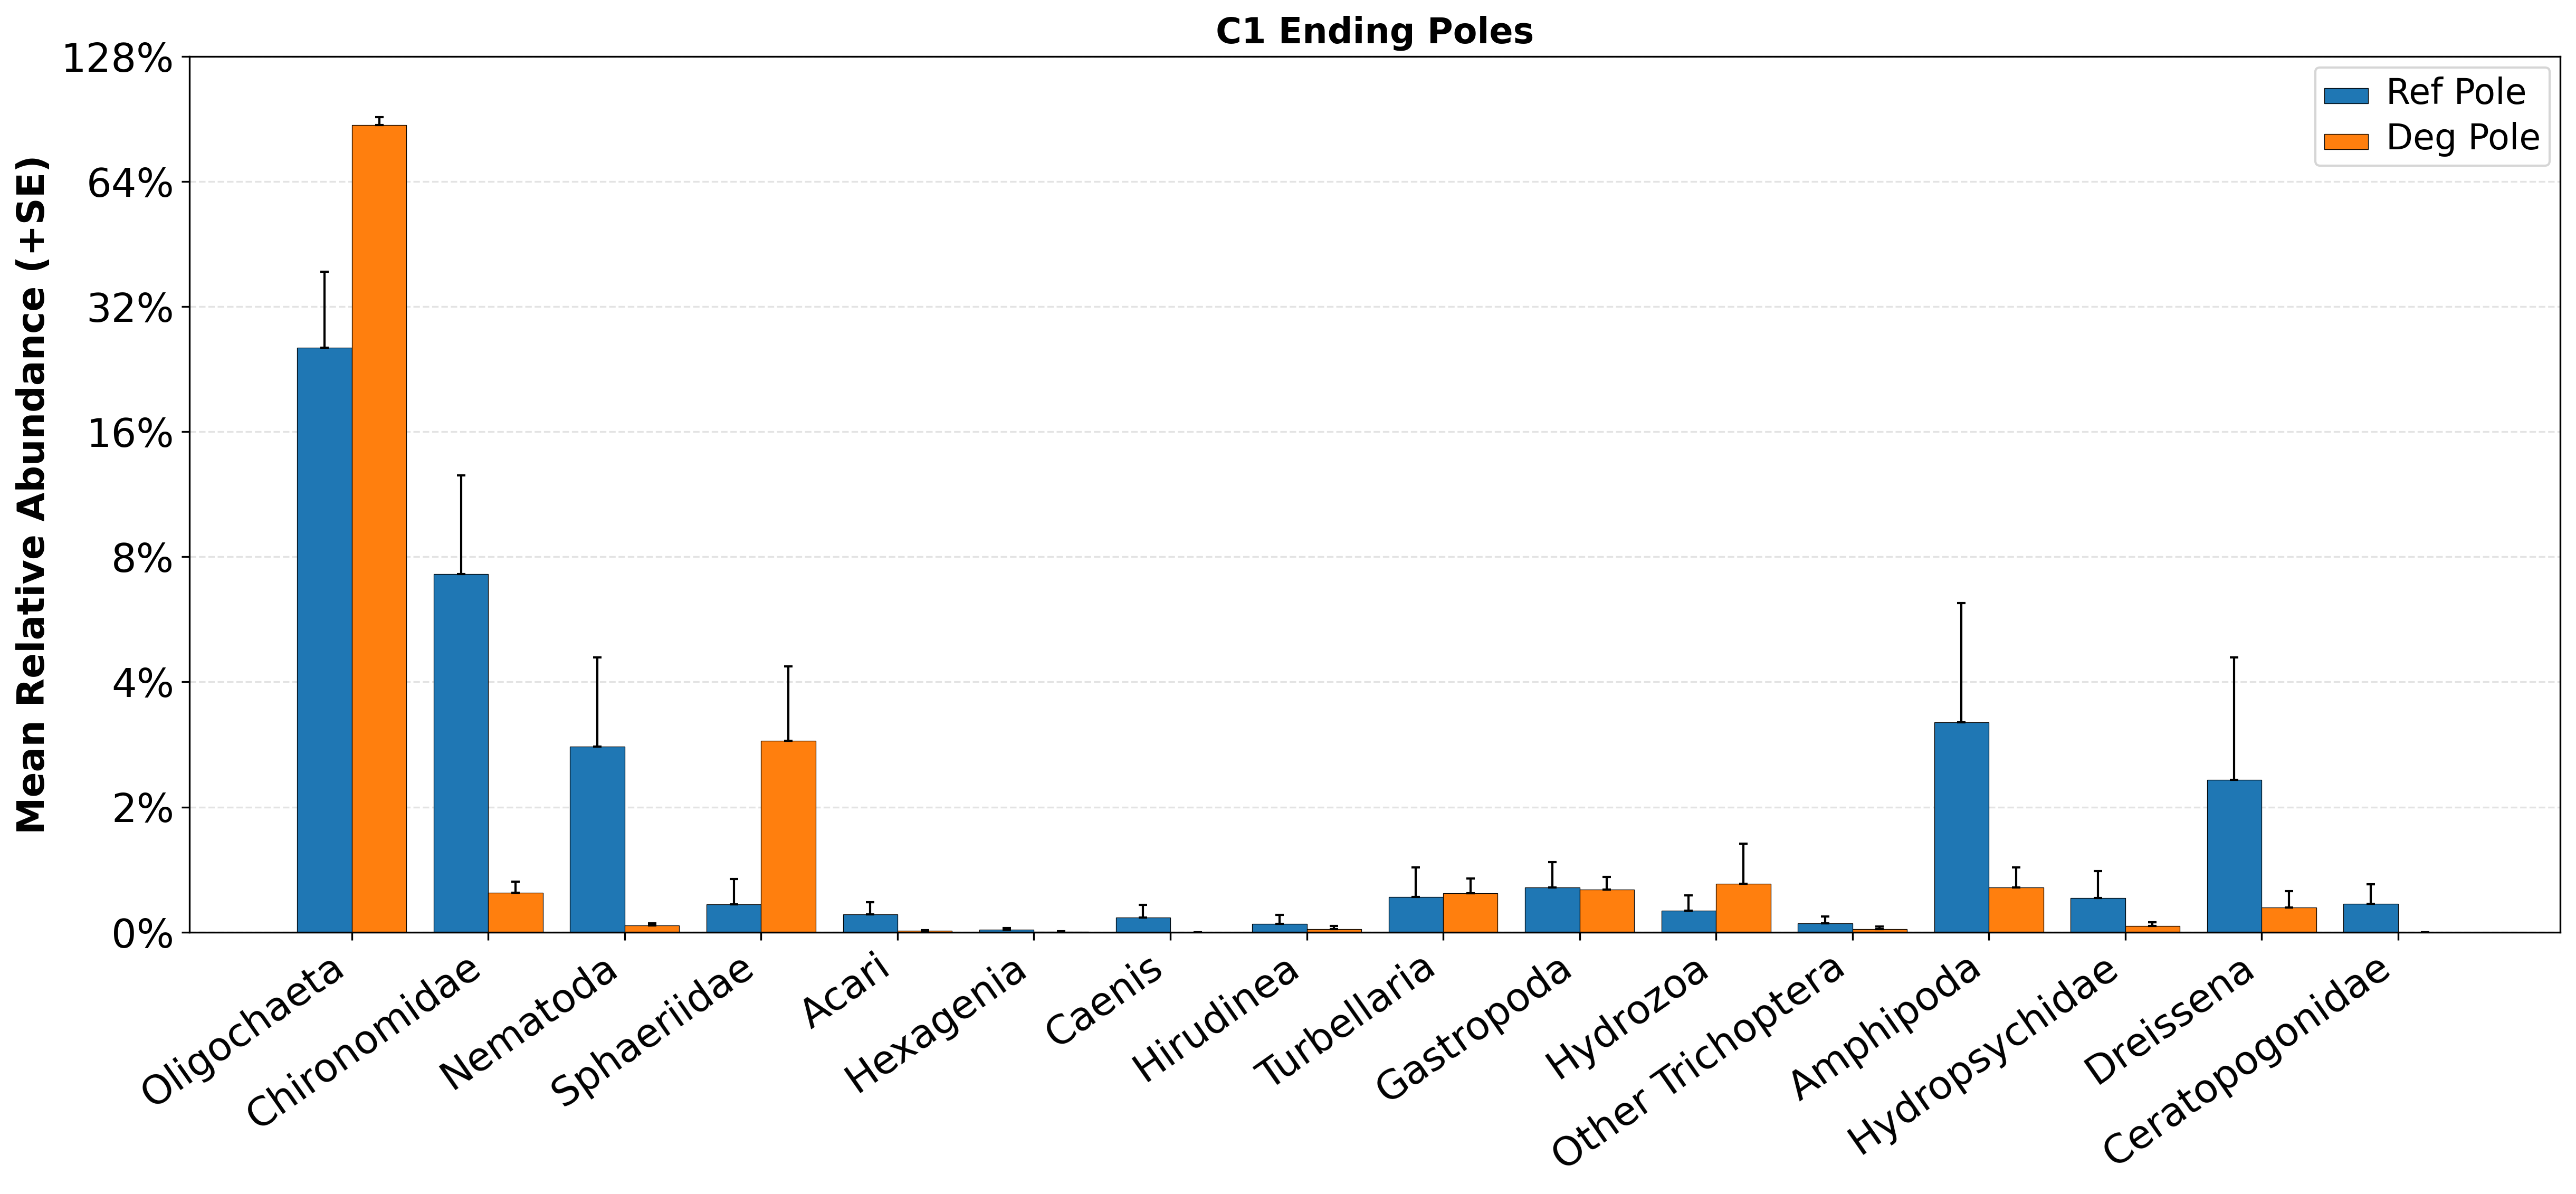

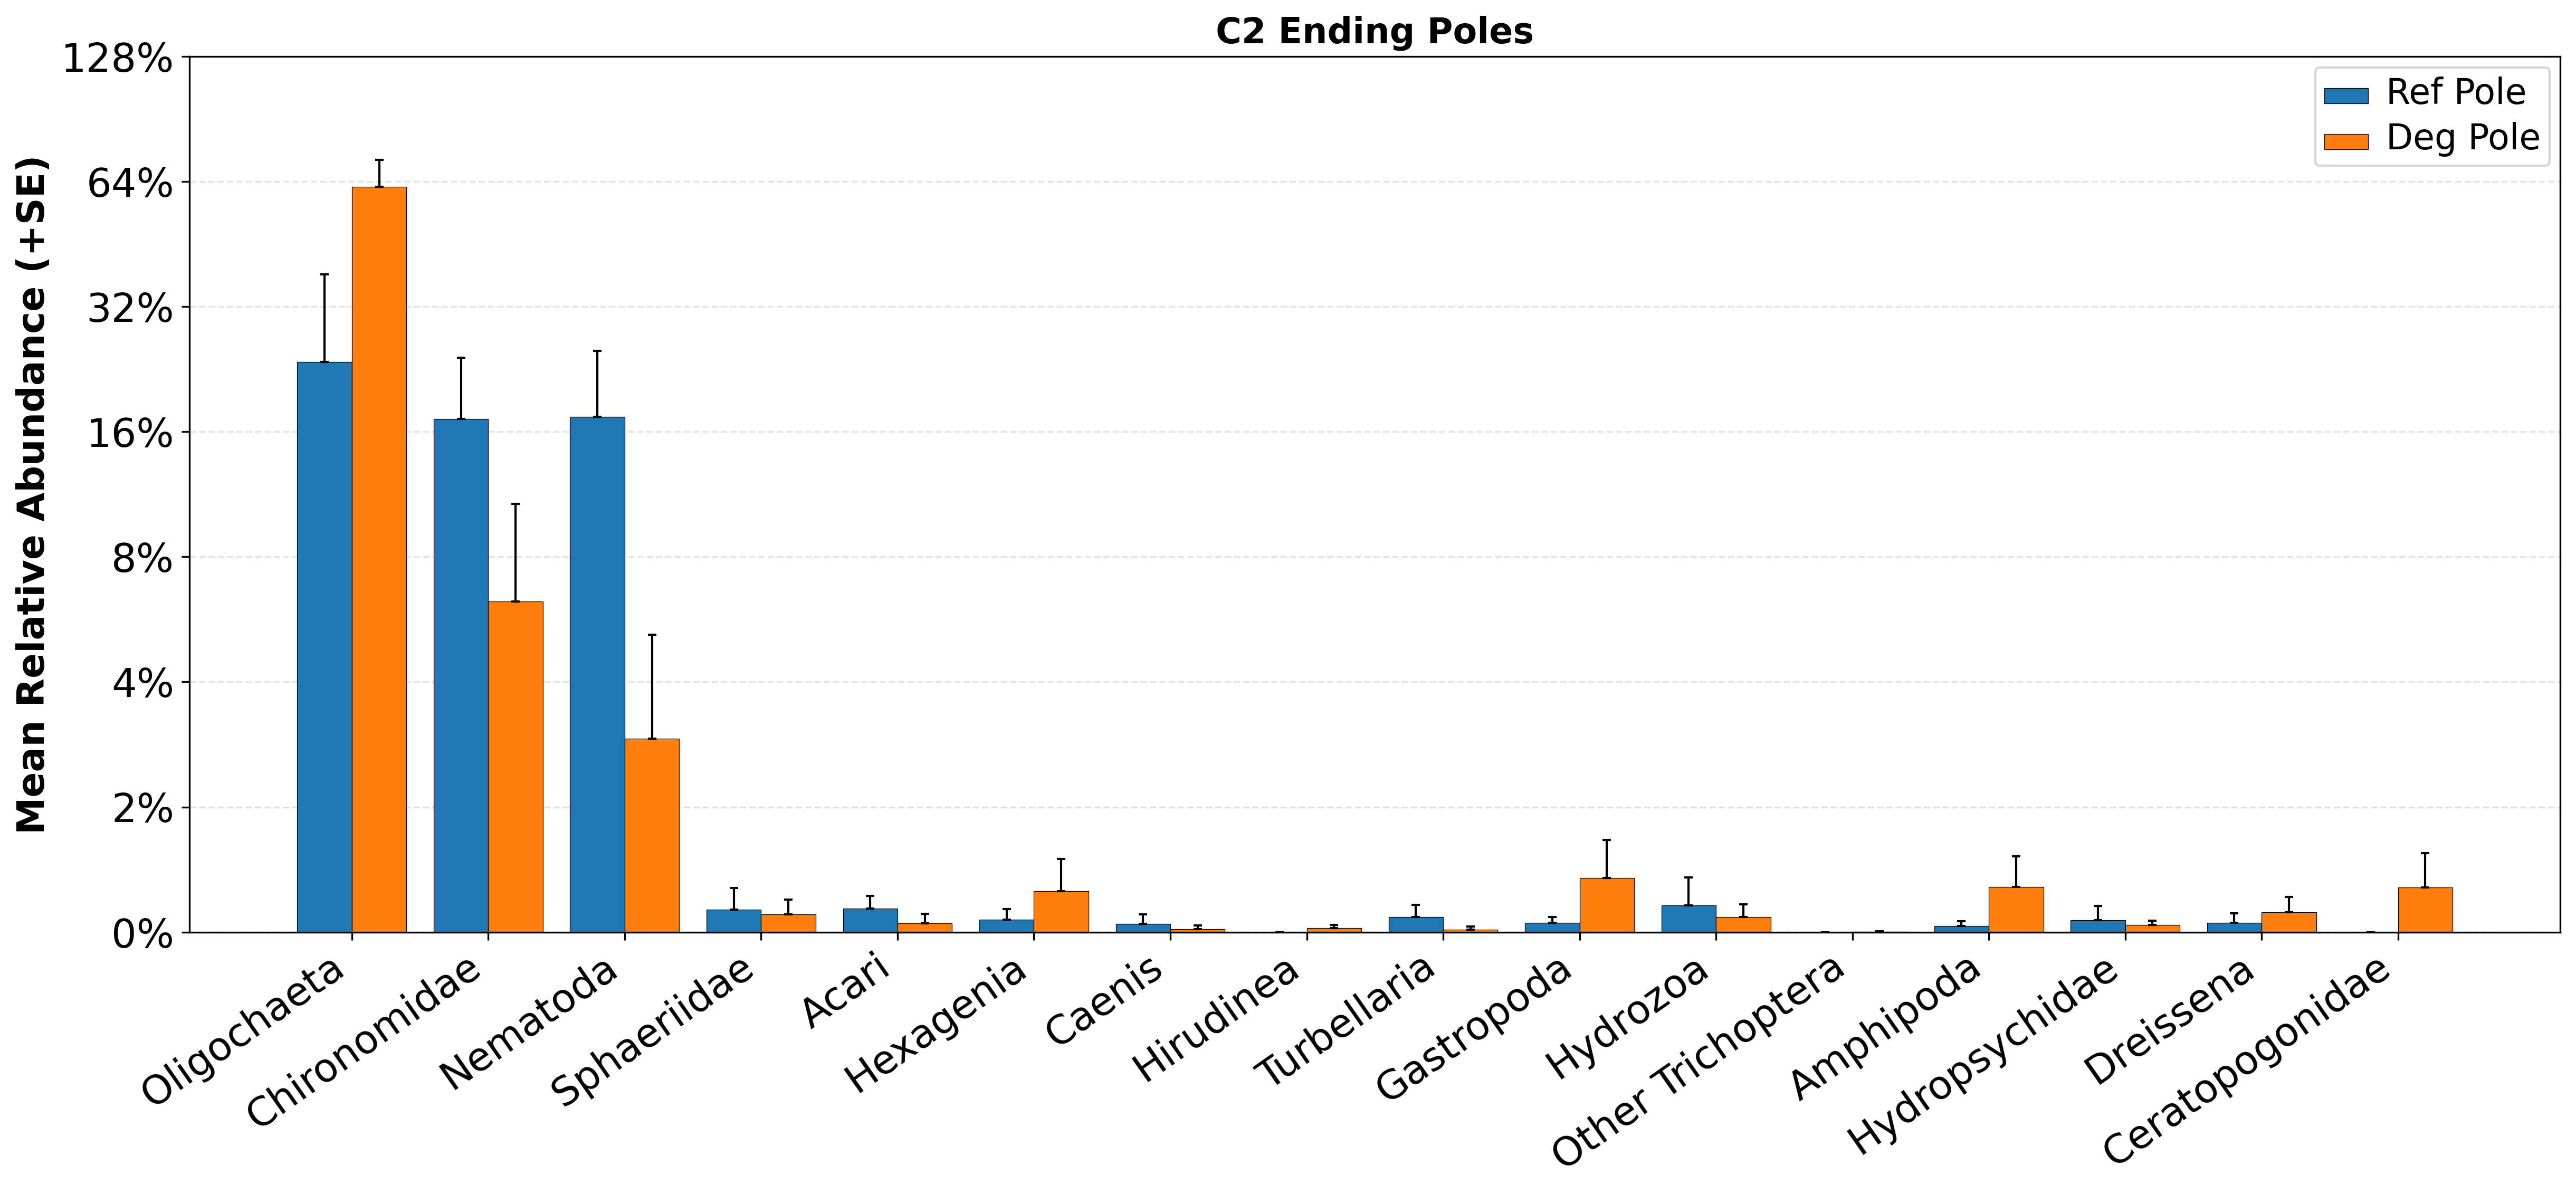

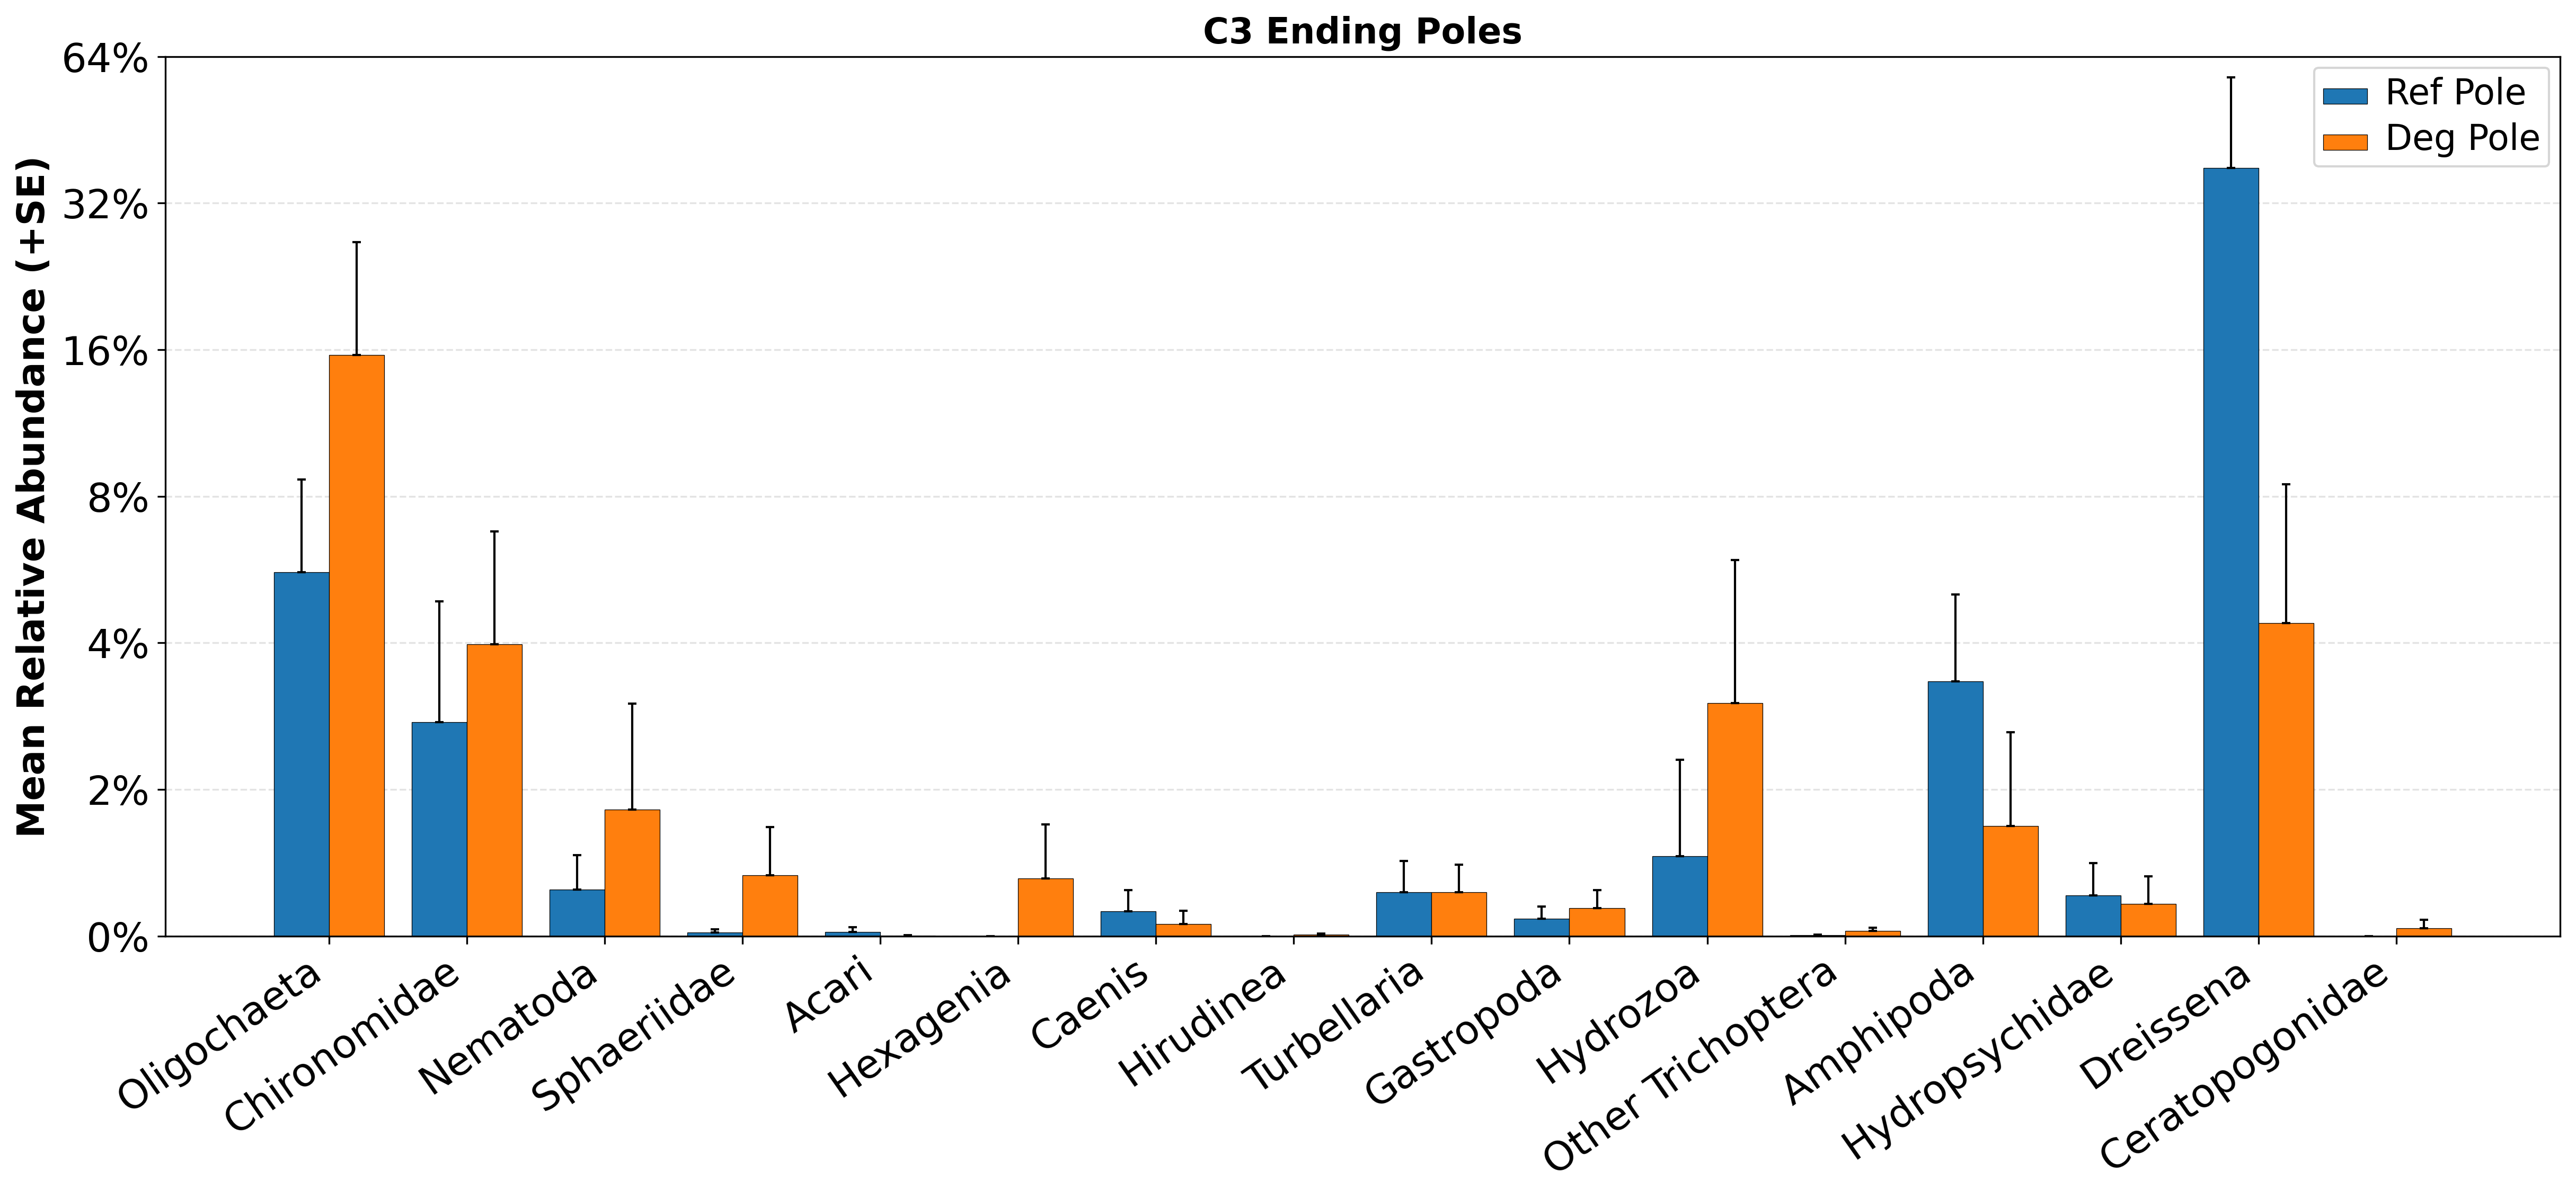

In [ ]:
display(C1_barplot_figure)
plt.close(C1_barplot_figure)

display(C2_barplot_figure)
plt.close(C2_barplot_figure)

if STUDY_CASE == "DR":
    display(C3_barplot_figure)
    plt.close(C3_barplot_figure)


# Execution summary

After a complete corridor-case run, this notebook produces:

```text
../artifacts/A7_C1_bray_curtis_dissimilarity_matrix.xlsx
../artifacts/A8_C2_bray_curtis_dissimilarity_matrix.xlsx
```

When `STUDY_CASE = "DR"`, the same output filenames are written under:

```text
../DetroitRiverCase/results/
../DetroitRiverCase/artifacts/
../DetroitRiverCase/figures/
```